<a href="https://colab.research.google.com/github/TaylorShiehUSI/Github-Colab-test/blob/main/PCA_1_%E5%88%86%E6%9E%90_3_2_mk10_cma_with_difficusion_ipynb_%E7%9A%84%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install cma

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 kB 5.0 MB/s eta 0:00:00


In [ ]:
import cma
import numpy as np
import random
import matplotlib.pyplot as plt
import os

# ========== 📦 讀入 Mk10.fjs 檔案 ==========
def load_data(path):
    try:
        with open(f"{path}.fjs", "r") as file:
            lines = file.readlines()
    except FileNotFoundError:
        raise FileNotFoundError(f"File {path}.fjs not found.")

    if not lines:
        raise ValueError("File is empty or improperly formatted.")

    try:
        num_jobs, num_machines = map(int, lines[0].strip().split()[:2])
    except Exception:
        raise ValueError("Header line parsing failed.")

    J, P = [], []
    for line in lines[1:]:
        data = list(map(int, line.strip().split()))
        if not data:
            continue
        try:
            ops = data[0]
            data = data[1:]
            jlist, plist = [], []
            i = 0
            for _ in range(ops):
                m = data[i]; i += 1
                mlist = [data[i + 2 * k] - 1 for k in range(m)]
                ptlist = [data[i + 2 * k + 1] for k in range(m)]
                jlist.append(mlist)
                plist.append(ptlist)
                i += 2 * m
        except IndexError:
            raise ValueError("Incomplete machine-time data.")
        J.append(jlist)
        P.append(plist)
    return J, P, num_machines

# ========== 🔧 工具函數：createInd / decode / drawGantt ==========
def createInd(n, J, P, split_list=None):
    if split_list is None:
        split_list = [10, 10, 20]
    pop = []
    total_ops = sum(len(job) for job in J)

    def normalize_ms(ms_list):
        ms_key = []
        flat_idx = 0
        for i in range(len(J)):
            for j in range(len(J[i])):
                m_len = len(J[i][j])
                r_key = ms_list[flat_idx] / m_len if m_len > 0 else 0.0
                ms_key.append(min(r_key, 1 - 1e-6))
                flat_idx += 1
        return ms_key

    def OS_random_key():
        return [random.random() for _ in range(total_ops)]

    def RS_mopsl():
        return [random.randint(0, len(J[i][j]) - 1) for i in range(len(J)) for j in range(len(J[i]))]

    gs = normalize_ms(RS_mopsl())
    ls = normalize_ms(RS_mopsl())
    rs = normalize_ms(RS_mopsl())

    for _ in range(split_list[0]): pop.append(gs + OS_random_key())
    for _ in range(split_list[1]): pop.append(ls + OS_random_key())
    for _ in range(split_list[2]): pop.append(rs + OS_random_key())

    return pop

def decode(J, P, s, n):
    s = np.clip(s, 0.0, 1.0)
    job_num = len(J)
    process_num = sum(len(job) for job in J)
    MS_key = s[:process_num]
    OS_key = s[process_num:]

    machine_list = []
    flat_idx = 0
    for i in range(len(J)):
        part = []
        for j in range(len(J[i])):
            m_list = J[i][j]
            rel_idx = int(MS_key[flat_idx] * len(m_list))
            rel_idx = min(rel_idx, len(m_list) - 1)
            part.append(rel_idx)
            flat_idx += 1
        machine_list.append(part)

    op_keys = []
    idx = 0
    for job_id in range(len(J)):
        for op_id in range(len(J[job_id])):
            op_keys.append((OS_key[idx], job_id))
            idx += 1
    op_keys.sort()
    OS = [job for key, job in op_keys]

    T = [[[0]] for _ in range(n)]
    C = np.zeros((job_num, max(len(job) for job in J)))
    k = np.zeros(job_num, dtype=int)

    for job in OS:
        op_id = k[job]
        rel_idx = machine_list[job][op_id]
        machine = J[job][op_id][rel_idx]
        p_time = P[job][op_id][rel_idx]
        last = C[job, op_id - 1] if op_id > 0 else 0
        start = max(last, T[machine][-1][-1])
        insert = len(T[machine])
        for i in range(1, len(T[machine])):
            gap_s = max(T[machine][i - 1][-1], last)
            gap_e = T[machine][i][0]
            if gap_e - gap_s >= p_time:
                start = gap_s
                insert = i
                break
        end = start + p_time
        C[job, op_id] = end
        T[machine].insert(insert, [start, job, op_id, end])
        k[job] += 1

    return T, C

import numpy as np
from sklearn.decomposition import PCA
import cma  # 若在 Colab 執行，請先 !pip install cma


def drawGantt(timeList):
    T = timeList.copy()
    fig, ax = plt.subplots(figsize=(12, 6))
    color_pool = plt.colormaps['tab20']
    color_map = {}
    for machine in T:
        for task in machine[1:]:
            job = task[1]
            if job not in color_map:
                color_map[job] = color_pool(job % 20)
    for i, machine in enumerate(T):
        for task in machine[1:]:
            st, job, op, et = task
            color = color_map[job]
            ax.barh(i, et - st, left=st, height=0.5, color=color, edgecolor='black')
            ax.text((st + et) / 2, i, f'{job}-{op}', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    ax.set_yticks(range(len(T)))
    ax.set_yticklabels([f'M{m+1}' for m in range(len(T))])
    ax.invert_yaxis()
    ax.set_xlabel("Time")
    ax.set_title("FJSP Gantt Chart", fontsize=14, fontweight='bold')
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


# ========== 🧠 CMA-ES + Plateau Detection ==========
def in_plateau(hist, w=15, thres=0.002):
    if len(hist) < w + 1: return False
    return (hist[-w-1] - min(hist[-w:])) / hist[-w-1] < thres



# ========== 🚀 主程式區段 ==========
dataset_path = "/content/drive/MyDrive/排程/Mk01"
if not os.path.exists(f"{dataset_path}.fjs"):
    raise FileNotFoundError(f"{dataset_path}.fjs 檔案不存在")

J, P, machine_num = load_data(dataset_path)


from scipy.stats import truncnorm

from scipy.stats import truncnorm
import numpy as np


# 🎯 真實無擾動評估
def evaluate_true(x, J, P, machine_num):
    x = np.clip(x, 0.0, 1.0)
    _, C = decode(J, P, x, machine_num)
    return C.max()

def evaluate_with_ranked_noise(solutions, J, P, machine_num, sigma=0.1, top_ratio=0.05):
    popsize = len(solutions)
    raw_fitnesses = [evaluate_true(x, J, P, machine_num) for x in solutions]

    # ➤ 排名：從小到大，取得索引
    ranks = np.argsort(raw_fitnesses)

    # ➤ 建立最終 fitness（含噪聲）
    ranked_fitnesses = raw_fitnesses[:]
    top_k = max(1, int(popsize * top_ratio))  # 至少挑一個

    for i in range(top_k):
        idx = ranks[i]
        noise = truncnorm.rvs(a=0, b=np.inf, loc=0, scale=sigma)  # 僅加正向 noise
        ranked_fitnesses[idx] += noise

    return ranked_fitnesses

import numpy as np
from sklearn.decomposition import PCA
from scipy.stats import truncnorm

# === Local Check + PCA 分析函數 ===
def inject_local_check_with_pca(es, best_solution, J, P, machine_num, radius=0.4, trials=90000, improvement_threshold=1.0):
    dim = len(best_solution)
    perturbations = np.random.uniform(-radius, radius, size=(trials, dim))
    local_solutions = best_solution + perturbations
    local_solutions = np.clip(local_solutions, 0.0, 1.0)

    local_fitnesses = [evaluate_true(x, J, P, machine_num) for x in local_solutions]
    local_best_idx = np.argmin(local_fitnesses)
    local_best_solution = local_solutions[local_best_idx]
    local_best_cmax = local_fitnesses[local_best_idx]

    best_cmax = evaluate_true(best_solution, J, P, machine_num)
    if local_best_cmax + improvement_threshold < best_cmax:
        delta = local_best_solution - best_solution
        pca = PCA(n_components=1)
        pca.fit(local_solutions)
        direction = pca.components_[0]
        projected = np.dot(delta, direction)
        if projected > 0:
            es.mean += 0.3 * direction
            return f"🔍 PCA-guided update: moved mean in principal direction (\u0394Cmax: {best_cmax - local_best_cmax:.2f})"
    return f"🔍 PCA-guided update: No Action"




init_pop = createInd(n=400, J=J, P=P, split_list=[100, 100, 200])
dim = len(init_pop[0])

es = cma.CMAEvolutionStrategy(
    init_pop[0], 0.3,
    {
        'popsize': 400,
        'bounds': [0.0, 1.0],
        'maxiter': 5000,
        'tolx': 0, 'tolfun': 0, 'tolfunhist': 0,
        'maxfevals': 1e7, 'verb_disp': 50,
        'CMA_elitist': True, 'CMA_active': True
    }
)


# === 主演化程式 ===
MAX_ITER, g, plateau_count = 300, 1, 0
penalty_dims = []
mean_trajectory = []
base_noise = 10
decay_factor = 0.86
history = []

# 第 0 代
solutions = es.ask()
solutions = init_pop
fitnesses = evaluate_with_ranked_noise(solutions, J, P, machine_num, sigma=0.2, top_ratio=0.05)
es.tell(solutions, fitnesses)
es.logger.add(); es.disp()
best = min(fitnesses)
history.append(best)
mean_trajectory.append(es.mean.copy())
print(f"Generation 0 | Best Cmax: {best} | (No Noise)")

# 🎬 主演化過程
while not es.stop() and g < MAX_ITER:
    solutions = es.ask()
    sigma = base_noise * (decay_factor ** (g / 50))

    fitnesses = evaluate_with_ranked_noise(solutions, J, P, machine_num, sigma=sigma, top_ratio=0.05)
    es.tell(solutions, fitnesses)
    es.logger.add(); es.disp()

    best = min(fitnesses)
    history.append(best)
    mean_trajectory.append(es.mean.copy())

    if sigma > 0:
        print(f"Generation {g} | Best Cmax: {best:.2f} | Noise Sigma: {sigma:.4f}")
    else:
        print(f"Generation {g} | Best Cmax: {best:.2f} | (Pure Exploration)")

    if len(history) > 20 and np.std(history[-20:]) < 1e-3:
        print(f"⚡ Plateau detected @ gen {g}, boosting sigma...")
        es.sigma *= 1.0

    # 每 50 代執行一次 local check + PCA 分析
    if g % 50 == 0:
        best_solution = es.best.get()[0]
        message = inject_local_check_with_pca(es, best_solution, J, P, machine_num,
                                              radius=0.2, trials=1000, improvement_threshold=1.0)
        if message:
            print(f"📌 Gen {g} | {message}")

    g += 1

# 最終結果
best_solution = es.best.get()[0]
true_cmax = evaluate_true(best_solution, J, P, machine_num)
print(f"\n🎯 Final Best Cmax (true evaluation): {true_cmax:.2f}")




(200_w,400)-aCMA-ES (mu_w=103.4,w_1=2%) in dimension 110 (seed=987048, Sun Jun 15 02:41:34 2025)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1    400 7.400000000000000e+01 1.0e+00 8.15e-01  3e-01  3e-01 0:00.8


/usr/local/lib/python3.11/dist-packages/cma/utilities/utils.py:349: UserWarning: sigma change np.exp(2.3205862104743558) = 10.18164114167508 clipped to np.exp(+-1) (time=Jun 15 02:41:34 2025 class=CMAAdaptSigmaCSA method=update iteration=1)
  warnings.warn(msg + ' (time={}'.format(time.asctime()[4:]) +


Generation 0 | Best Cmax: 74.0 | (No Noise)
    2    800 6.714299773397502e+01 1.8e+00 2.22e+00  3e-01  3e-01 0:01.7


/usr/local/lib/python3.11/dist-packages/cma/utilities/utils.py:349: UserWarning: sigma change np.exp(1.0562628295415446) = 2.8756042599571536 clipped to np.exp(+-1) (time=Jun 15 02:41:35 2025 class=CMAAdaptSigmaCSA method=update iteration=2)
  warnings.warn(msg + ' (time={}'.format(time.asctime()[4:]) +


Generation 1 | Best Cmax: 67.14 | Noise Sigma: 9.9699
    3   1200 6.611385362636734e+01 1.8e+00 3.58e+00  3e-01  3e-01 0:02.5
Generation 2 | Best Cmax: 66.11 | Noise Sigma: 9.9399
Generation 3 | Best Cmax: 62.57 | Noise Sigma: 9.9099
Generation 4 | Best Cmax: 63.28 | Noise Sigma: 9.8801
    6   2400 5.809640956505491e+01 1.8e+00 5.74e+00  3e-01  3e-01 0:05.6
Generation 5 | Best Cmax: 58.10 | Noise Sigma: 9.8503
Generation 6 | Best Cmax: 55.55 | Noise Sigma: 9.8206
Generation 7 | Best Cmax: 57.23 | Noise Sigma: 9.7911
Generation 8 | Best Cmax: 56.91 | Noise Sigma: 9.7616
Generation 9 | Best Cmax: 54.53 | Noise Sigma: 9.7322
Generation 10 | Best Cmax: 54.09 | Noise Sigma: 9.7029
   12   4800 5.753097973883138e+01 1.8e+00 8.78e+00  3e-01  3e-01 0:09.8
Generation 11 | Best Cmax: 57.53 | Noise Sigma: 9.6736
Generation 12 | Best Cmax: 55.93 | Noise Sigma: 9.6445
Generation 13 | Best Cmax: 55.07 | Noise Sigma: 9.6154
Generation 14 | Best Cmax: 50.12 | Noise Sigma: 9.5865
Generation 15 | Best

In [ ]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import truncnorm
from functools import partial

# 假設已有 evaluate_true, best_solution, solutions（最後一代族群）
# evaluate_true(x, J, P, machine_num): -> returns Cmax
# best_solution: CMA-ES 最佳解
# solutions: 最後一代族群解（用來計算排名）

def objective_for_lbfgs_with_rank(x, all_solutions, J, P, machine_num, sigma=0.1, top_ratio=0.05):
    """
    模擬 ranked-based noise 的單解評估函數。
    L-BFGS 每次評估 x，會根據其在族群中的排名決定是否加噪聲。
    """
    # 評估整體族群的真實 fitness
    raw_fitnesses = [evaluate_true(sol, J, P, machine_num) for sol in all_solutions]
    target_fitness = evaluate_true(x, J, P, machine_num)

    # 合併並排序
    all_fitnesses = raw_fitnesses + [target_fitness]
    ranks = np.argsort(all_fitnesses)
    x_rank = np.where(ranks == len(all_fitnesses) - 1)[0][0]  # x 是最後插入的

    popsize = len(all_solutions) + 1
    top_k = max(1, int(popsize * top_ratio))

    if x_rank < top_k:
        noise = truncnorm.rvs(a=0, b=np.inf, loc=0, scale=sigma)
        # return target_fitness + noise
        return target_fitness
    else:
        return target_fitness

# 假設已有最後一代族群 solutions
reference_population = solutions  # 最後一代的族群

# 封裝為 L-BFGS 的單點目標函數
wrapped_objective = partial(
    objective_for_lbfgs_with_rank,
    all_solutions=reference_population,
    J=J,
    P=P,
    machine_num=machine_num,
    sigma=0.1,
    top_ratio=0.05
)

# 🔧 使用 L-BFGS 微調（⚠會受到 noise 擾動影響）
res = minimize(
    wrapped_objective,
    x0=best_solution,
    method='L-BFGS-B',
    options={'maxiter': 100, 'disp': True}
)

# 🎯 結果
final_solution = res.x
final_cmax = res.fun

print(f"\n⚠️ L-BFGS + rank-based noise 結果（可能不穩定）: {final_cmax:.2f}")




⚠️ L-BFGS + rank-based noise 結果（可能不穩定）: 42.00


In [ ]:
# 📌 Step 1: 在 best_solution 附近每一維 ±0.2 範圍內產生 10000 組解
local_trials = 10000
dim = len(best_solution)

# ➤ 建立 perturbation：每一維 uniform(-0.05, +0.05)
perturbations = np.random.uniform(-0.05, 0.05, size=(local_trials, dim))
local_solutions = best_solution + perturbations

# ➤ 避免超出 [0, 1] 的邊界（若有這限制的話）
local_solutions = np.clip(local_solutions, 0.0, 1.0)

# 📌 Step 2: 評估這些鄰近點的 true fitness（無噪聲）
local_fitnesses = [evaluate_true(x, J, P, machine_num) for x in local_solutions]
local_best = np.min(local_fitnesses)
local_avg = np.mean(local_fitnesses)

# 📌 Step 3: 也評估你的 L-BFGS 結果（用 true evaluate）
true_final_cmax = evaluate_true(final_solution, J, P, machine_num)

# 📌 Step 4: 輸出比較結果
print(f"\n📍 Best Solution ±0.05 區域內隨機解 Best: {local_best:.2f}")
print(f"📉 Best Solution ±0.05 區域內隨機解 Avg : {local_avg:.2f}")
print(f"⚙️ L-BFGS 微調結果 (True Eval): {true_final_cmax:.2f}")

T, C = decode(J, P, final_solution, machine_num)


📍 Best Solution ±0.05 區域內隨機解 Best: 42.00
📉 Best Solution ±0.05 區域內隨機解 Avg : 44.82
⚙️ L-BFGS 微調結果 (True Eval): 42.00


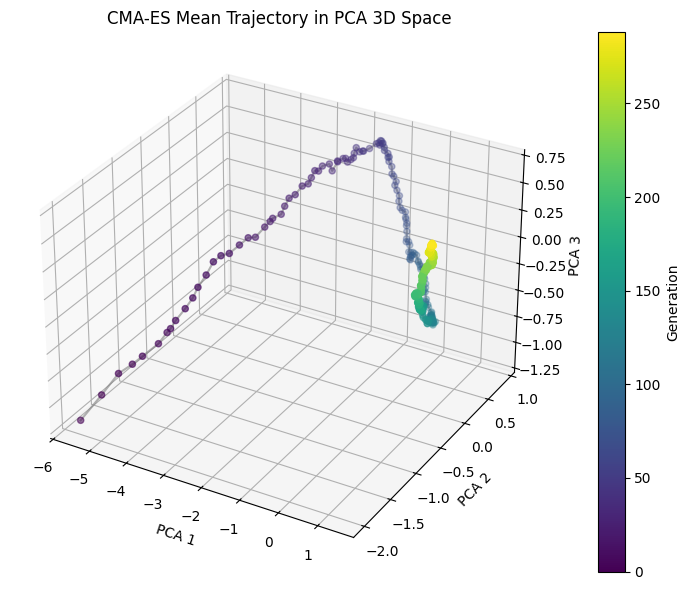

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# ✅ 若尚未轉成 numpy array
mean_trajectory = np.array(mean_trajectory)  # ← 解決 .shape 問題
G, dim = mean_trajectory.shape

# 加入 log(代數) 作為輔助變數，引導 PCA 保留時間結構
augmented = np.hstack([mean_trajectory, np.log1p(np.arange(G)).reshape(-1, 1)])

# 做 PCA 降到 4 維
pca = PCA(n_components=4)
proj = pca.fit_transform(augmented)

# 取前 3 維做為 3D 空間，顏色為「代數」
x, y, z = proj[:, 0], proj[:, 1], proj[:, 2]
color = np.arange(G)

# 畫圖
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(x, y, z, c=color, cmap='viridis', marker='o')
ax.plot(x, y, z, color='gray', alpha=0.6)

ax.set_title("CMA-ES Mean Trajectory in PCA 3D Space")
ax.set_xlabel("PCA 1"); ax.set_ylabel("PCA 2"); ax.set_zlabel("PCA 3")
fig.colorbar(p, label="Generation")
plt.tight_layout(); plt.show()




<ipython-input-6-3939734547>:50: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-3939734547>:50: UserWarning: Glyph 36600 (\N{CJK UNIFIED IDEOGRAPH-8EF8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-3939734547>:50: UserWarning: Glyph 23565 (\N{CJK UNIFIED IDEOGRAPH-5C0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-3939734547>:50: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-3939734547>:50: UserWarning: Glyph 24501 (\N{CJK UNIFIED IDEOGRAPH-5FB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-3939734547>:50: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-6-3939734547>:50: UserWarning: Glyph 36002 (\N{CJK UNIFIED IDEOGRAPH-8CA2}) missing from font(s) DejaVu Sans.

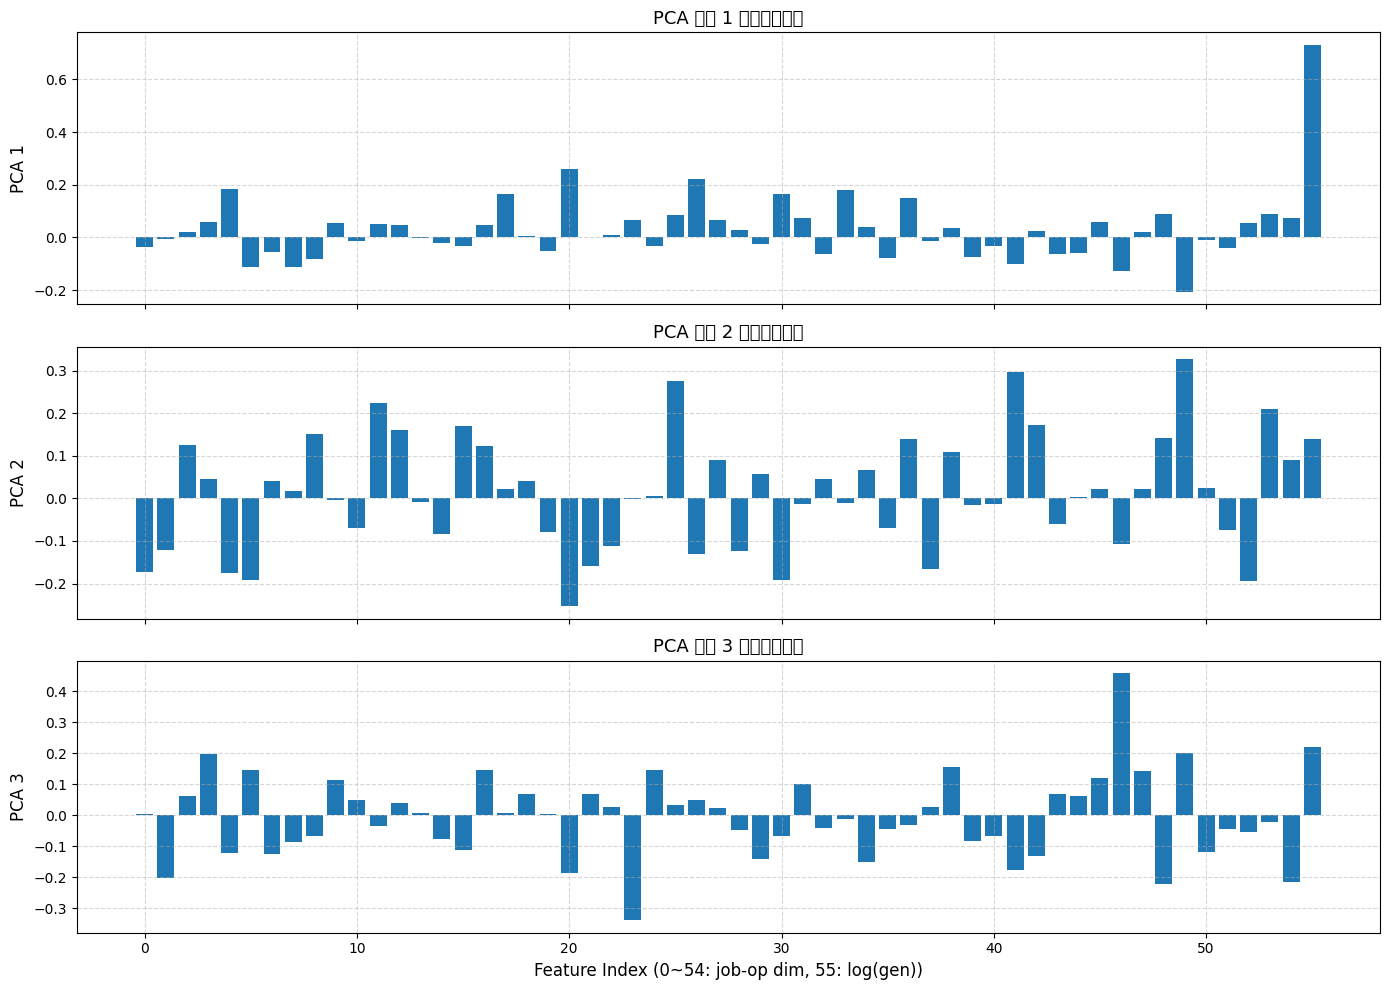


🔹 PCA 1 Top-5 contributing features:
  log(gen)   → Weight:  0.7318
  J3-O4      → Weight:  0.2598
  J4-O5      → Weight:  0.2233
  J9-O0      → Weight: -0.2075
  J0-O4      → Weight:  0.1842

🔹 PCA 2 Top-5 contributing features:
  J9-O0      → Weight:  0.3272
  J7-O3      → Weight:  0.2955
  J4-O4      → Weight:  0.2764
  J3-O4      → Weight: -0.2529
  J2-O0      → Weight:  0.2245

🔹 PCA 3 Top-5 contributing features:
  J8-O3      → Weight:  0.4588
  J4-O2      → Weight: -0.3390
  J8-O5      → Weight: -0.2218
  log(gen)   → Weight:  0.2200
  J9-O5      → Weight: -0.2140

📘 PCA 1 全特徵排序（前 5）：
 Feature   Loading
log(gen)  0.731801
   J3-O4  0.259758
   J4-O5  0.223280
   J9-O0 -0.207473
   J0-O4  0.184187

📘 PCA 2 全特徵排序（前 5）：
Feature   Loading
  J9-O0  0.327237
  J7-O3  0.295484
  J4-O4  0.276360
  J3-O4 -0.252920
  J2-O0  0.224524

📘 PCA 3 全特徵排序（前 5）：
 Feature   Loading
   J8-O3  0.458794
   J4-O2 -0.338976
   J8-O5 -0.221830
log(gen)  0.219974
   J9-O5 -0.213962

📌 log(generation) 在前三

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd

# 假設已存在以下變數：
# mean_trajectory：包含 MS_key + OS_key 的演化結果 (G, dim)
# J：job-operation 結構，例如 J[i][j] 表示第 i 個 job 的第 j 道工序的機台清單

# ====== 🎯 Step 1：分離 MS_key，加入 log(generation) ======
ms_dim = sum(len(job) for job in J)
MS_key = mean_trajectory[:, :ms_dim]
OS_key = mean_trajectory[:, ms_dim:]  # 可選用於未來分析

G = mean_trajectory.shape[0]
log_gen = np.log1p(np.arange(G)).reshape(-1, 1)
augmented = np.hstack([MS_key, log_gen])
dim = MS_key.shape[1]

# ====== 🧭 Step 2：建立 dim → (Job ID, Op ID) 對應表 ======
dim_to_jobop = []
for job_id, job in enumerate(J):
    for op_id in range(len(job)):
        dim_to_jobop.append((job_id, op_id))

def explain_dim(dim_index):
    if dim_index == dim:
        return "log(gen)"
    elif 0 <= dim_index < len(dim_to_jobop):
        job_id, op_id = dim_to_jobop[dim_index]
        return f"J{job_id}-O{op_id}"
    else:
        return f"dim {dim_index} ❓"

# ====== 🚀 Step 3：執行 PCA 分析 ======
pca = PCA(n_components=4)
pca.fit(augmented)
pca_components = pca.components_[:3]  # 前三主軸

# ====== 📊 Step 4：畫出每個主軸對特徵的 loading bar chart ======
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for i in range(3):
    ax = axes[i]
    ax.bar(np.arange(dim + 1), pca_components[i])
    ax.set_ylabel(f"PCA {i+1}", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_title(f"PCA 主軸 {i+1} 對特徵的貢獻", fontsize=13)
    if i == 2:
        ax.set_xlabel(f"Feature Index (0~{dim-1}: job-op dim, {dim}: log(gen))", fontsize=12)
plt.tight_layout()
plt.show()

# ====== 🔍 Step 5：輸出 Top-k 特徵（含 job-op 語意） ======
top_k = 5
for i in range(3):
    print(f"\n🔹 PCA {i+1} Top-{top_k} contributing features:")
    indices = np.argsort(np.abs(pca_components[i]))[::-1][:top_k]
    for idx in indices:
        label = explain_dim(idx)
        weight = pca_components[i][idx]
        print(f"  {label:10s} → Weight: {weight: .4f}")

# ====== 📋 Step 6：DataFrame 格式輸出（完整排序，便於後處理） ======
for i in range(3):
    data = []
    for idx, val in enumerate(pca_components[i]):
        label = explain_dim(idx)
        data.append((label, val))
    df = pd.DataFrame(data, columns=["Feature", "Loading"])
    df["Abs"] = df["Loading"].abs()
    df = df.sort_values("Abs", ascending=False).drop("Abs", axis=1)
    print(f"\n📘 PCA {i+1} 全特徵排序（前 {top_k}）：")
    print(df.head(top_k).to_string(index=False))

# ====== 🧠 Step 7：觀察 log(generation) 在主軸中的角色 ======
print("\n📌 log(generation) 在前三主軸中的 loading 值：")
for i in range(3):
    print(f"  PCA {i+1}: {pca_components[i][dim]: .4f}")





📘 PCA1 Top-4 contributing features:
   Feature   Loading
  log(gen)    0.7318
     J3-O4    0.2598
     J4-O5    0.2233
     J9-O0   -0.2075

📘 PCA2 Top-4 contributing features:
   Feature   Loading
     J9-O0    0.3272
     J7-O3    0.2955
     J4-O4    0.2764
     J3-O4   -0.2529

📘 PCA3 Top-4 contributing features:
   Feature   Loading
     J8-O3    0.4588
     J4-O2   -0.3390
     J8-O5   -0.2218
  log(gen)    0.2200

🔍 All highlighted operations (union):
{'3-4', '9-0', '8-5', '4-5', '7-3', '8-3', '4-2', '4-4'}
🔵 Critical Path Operations (unordered set):
這些工序位於整體排程中的最長依賴路徑上，也就是決定 Cmax 的瓶頸鏈：

{'2-3', '7-0', '3-2', '0-0', '5-2', '6-2', '8-1', '0-1', '1-2', '8-0', '0-2', '2-4', '5-4', '5-5'}


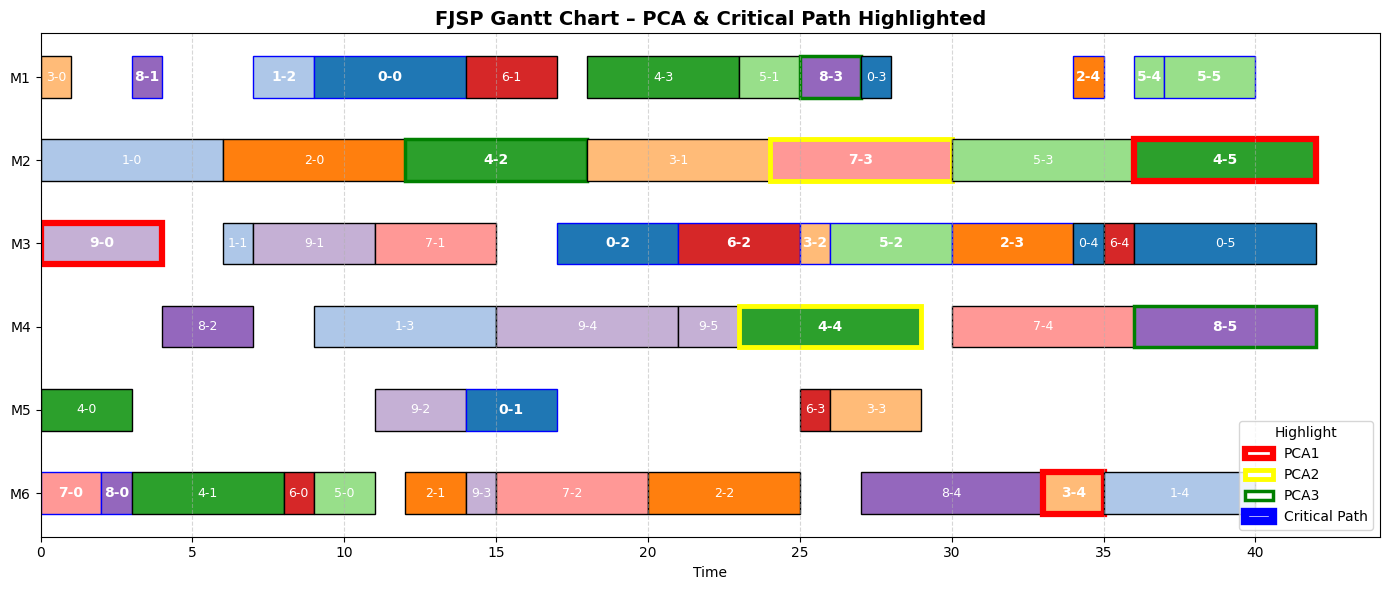

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd

# ========== STEP 1: 資料前處理 ==========
# 假設：你已擁有以下變數：
# mean_trajectory: shape = (G, dim_total) = [MS_key | OS_key]
# J: job-operation 結構，例如 J[i][j] 表示第 i 個 job 的第 j 道工序的機台選擇

# 分離 MS_key
ms_dim = sum(len(job) for job in J)
MS_key = mean_trajectory[:, :ms_dim]
OS_key = mean_trajectory[:, ms_dim:]  # 可另作分析
dim = MS_key.shape[1]

# 加入 log(generation)
G = mean_trajectory.shape[0]
log_gen = np.log1p(np.arange(G)).reshape(-1, 1)
augmented = np.hstack([MS_key, log_gen])

# ========== STEP 2: 建立 dim → job-op 對應表 ==========
dim_to_jobop = [(job_id, op_id) for job_id, job in enumerate(J) for op_id in range(len(job))]

def explain_dim(dim_index):
    if dim_index == dim:
        return "log(gen)"
    elif 0 <= dim_index < len(dim_to_jobop):
        job_id, op_id = dim_to_jobop[dim_index]
        return f"J{job_id}-O{op_id}"
    else:
        return f"dim {dim_index} ❓"

# ========== STEP 3: 執行 PCA ==========
pca = PCA(n_components=4)
pca.fit(augmented)
pca_components = pca.components_[:3]

# ========== STEP 4: 擷取 Top-k 高貢獻工序 ==========
# ====== 🔍 詳細列出每個 PCA 的 top-k 工序 ======
top_k = 4
pca_highlight_dict = {}  # 儲存每個主軸對應的工序集合

for i in range(3):
    pca_label = f"PCA{i+1}"
    pca_highlight_dict[pca_label] = set()
    indices = np.argsort(np.abs(pca_components[i]))[::-1][:top_k]

    print(f"\n📘 {pca_label} Top-{top_k} contributing features:")
    print(f"{'Feature':>10s}  {'Loading':>8s}")

    for idx in indices:
        label = explain_dim(idx)
        weight = pca_components[i][idx]
        print(f"{label:>10s}  {weight:8.4f}")

        # 加入 highlight dict（僅加入 MS_key 對應的工序）
        if idx < dim:
            job_id, op_id = dim_to_jobop[idx]
            pca_highlight_dict[pca_label].add(f"{job_id}-{op_id}")

# ✅ 合併所有 highlight 的工序總表
highlight_ops = set().union(*pca_highlight_dict.values())

print("\n🔍 All highlighted operations (union):")
print(highlight_ops)



# ========== STEP 5: 繪圖 - Gantt 標記高貢獻工序 ==========
import networkx as nx

def extract_critical_path_dag(T):
    """
    從 Gantt 資料 T 建立有向圖 (DAG)，並找出 longest path，即 Critical Path。
    返回：set of "job-op" 字串，例如 {"0-0", "3-2", ...}
    """
    G = nx.DiGraph()
    op_time = {}  # 每個 (job, op) 對應的處理時間

    # 建立節點與處理時間
    for m_id, machine in enumerate(T):
        for task in machine[1:]:
            st, job, op, et = task
            label = (job, op)
            duration = et - st
            G.add_node(label)
            op_time[label] = duration

    # Job 順序邊：Jx-O0 → Jx-O1 → ...
    job_ops = {}
    for machine in T:
        for task in machine[1:]:
            job = task[1]
            op = task[2]
            job_ops.setdefault(job, []).append((task[0], op))  # (start_time, op)

    for job, ops in job_ops.items():
        ops_sorted = sorted(ops, key=lambda x: x[1])  # op 順序
        for i in range(len(ops_sorted) - 1):
            u = (job, ops_sorted[i][1])
            v = (job, ops_sorted[i+1][1])
            G.add_edge(u, v)

    # Machine 順序邊：根據開始時間排序，同機器上的依賴
    for machine in T:
        tasks_sorted = sorted(machine[1:], key=lambda x: x[0])  # 按開始時間
        for i in range(len(tasks_sorted) - 1):
            u = (tasks_sorted[i][1], tasks_sorted[i][2])
            v = (tasks_sorted[i+1][1], tasks_sorted[i+1][2])
            G.add_edge(u, v)

    # 指定節點權重（工序 duration）
    for node in G.nodes:
        G.nodes[node]['weight'] = op_time[node]

    # 找出最長路徑
    longest_path = nx.dag_longest_path(G, weight='weight')

    # 回傳為 job-op 格式
    return {f"{j}-{o}" for j, o in longest_path}




def drawGantt_highlight_by_pca_cp(T, pca_highlight_dict, critical_ops):
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    fig, ax = plt.subplots(figsize=(14, 6))
    color_pool = plt.colormaps['tab20']
    color_map = {}

    # 色碼設定
    pca_color_map = {
        "PCA1": "red",
        "PCA2": "yellow",
        "PCA3": "green"
    }
    pca_linewidth_map = {
        "PCA1": 4.5,
        "PCA2": 3.5,
        "PCA3": 2.5
    }
    critical_color = "blue"
    critical_linewidth = 1.0

    # 建立 job 色彩對應
    for machine in T:
        for task in machine[1:]:
            job = task[1]
            if job not in color_map:
                color_map[job] = color_pool(job % 20)

    for i, machine in enumerate(T):
        for task in machine[1:]:
            st, job, op, et = task
            label = f"{job}-{op}"
            color = color_map[job]
            edgecolor = "black"
            linewidth = 1.0
            fontsize = 9
            fontweight = "normal"

            # ➤ 優先標記 Critical Path
            if label in critical_ops:
                edgecolor = critical_color
                linewidth = critical_linewidth
                fontsize = 10
                fontweight = "bold"
            else:
                # ➤ 否則查找是否為 PCA 標記
                for pca, op_set in pca_highlight_dict.items():
                    if label in op_set:
                        edgecolor = pca_color_map.get(pca, "black")
                        linewidth = pca_linewidth_map.get(pca, 3.0)
                        fontsize = 10
                        fontweight = "bold"
                        break

            ax.barh(i, et - st, left=st, height=0.5,
                    color=color, edgecolor=edgecolor, linewidth=linewidth)
            ax.text((st + et) / 2, i, label, ha='center', va='center',
                    color='white', fontsize=fontsize, fontweight=fontweight)

    ax.set_yticks(range(len(T)))
    ax.set_yticklabels([f"M{m+1}" for m in range(len(T))])
    ax.invert_yaxis()
    ax.set_xlabel("Time")
    ax.set_title("FJSP Gantt Chart – PCA & Critical Path Highlighted", fontsize=14, fontweight='bold')
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)

    # 📘 Legend
    legend_elements = [
        Patch(facecolor='white', edgecolor='red', linewidth=4.5, label="PCA1"),
        Patch(facecolor='white', edgecolor='yellow', linewidth=3.5, label="PCA2"),
        Patch(facecolor='white', edgecolor='green', linewidth=2.5, label="PCA3"),
        Patch(facecolor='white', edgecolor='blue', linewidth=6.0, label="Critical Path"),
    ]
    ax.legend(handles=legend_elements, loc="lower right", title="Highlight")

    plt.tight_layout()
    plt.show()


# ✅ 呼叫繪圖
critical_ops = extract_critical_path_dag(T)

# 3️⃣ 加上註解說明後列印
print("🔵 Critical Path Operations (unordered set):")
print("這些工序位於整體排程中的最長依賴路徑上，也就是決定 Cmax 的瓶頸鏈：\n")
print(critical_ops)

drawGantt_highlight_by_pca_cp(T, pca_highlight_dict, critical_ops)
# drawGantt_highlight_by_pca(T, pca_highlight_dict)


/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


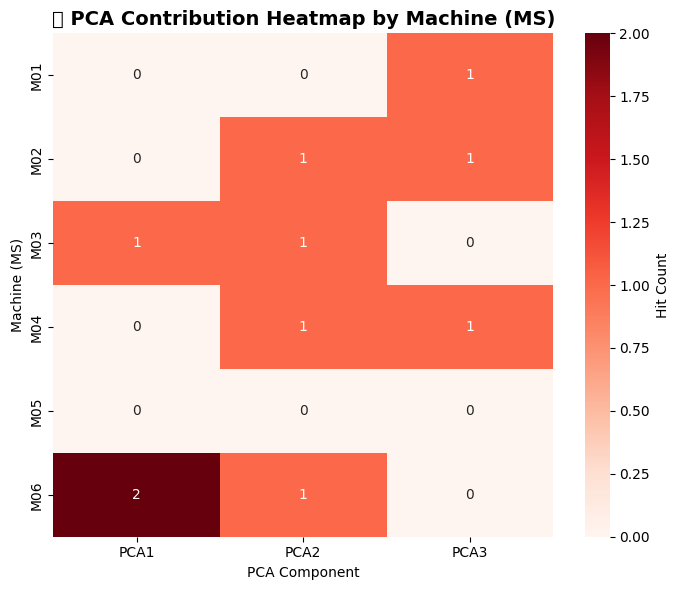

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def analyze_ms_pca_heatmap(J, s, pca_highlight_dict, machine_num):
    """
    輸出熱點圖：統計每個 PCA 對應的高貢獻工序，在 MS 選擇後落在哪些機台上。

    參數：
    - J: Job-Operation 結構
    - s: 某個個體解，例如 mean_trajectory[-1]
    - pca_highlight_dict: {'PCA1': {'job-op', ...}, ...}
    - machine_num: 總機台數
    """
    s = np.clip(s, 0.0, 1.0)
    ms_dim = sum(len(job) for job in J)
    MS_key = s[:ms_dim]

    dim_to_jobop = [(job_id, op_id) for job_id, job in enumerate(J) for op_id in range(len(job))]

    jobop_to_machine = {}
    for i, (job_id, op_id) in enumerate(dim_to_jobop):
        m_list = J[job_id][op_id]
        rel_idx = int(MS_key[i] * len(m_list))
        rel_idx = min(rel_idx, len(m_list) - 1)
        machine = m_list[rel_idx]
        jobop_to_machine[f"{job_id}-{op_id}"] = machine

    df = pd.DataFrame(0, index=[f"M{m+1:02d}" for m in range(machine_num)], columns=["PCA1", "PCA2", "PCA3"])
    for pca in pca_highlight_dict:
        for op in pca_highlight_dict[pca]:
            if op in jobop_to_machine:
                m = jobop_to_machine[op]
                df.at[f"M{m+1:02d}", pca] += 1

    # 🔥 熱點圖
    plt.figure(figsize=(7, 6))
    plt.title("🔥 PCA Contribution Heatmap by Machine (MS)", fontsize=14, weight='bold')
    sns = __import__('seaborn')
    sns.heatmap(df, annot=True, fmt='d', cmap='Reds', cbar_kws={'label': 'Hit Count'})
    plt.ylabel("Machine (MS)")
    plt.xlabel("PCA Component")
    plt.tight_layout()
    plt.show()

    return df


s = mean_trajectory[-1]
df_heatmap = analyze_ms_pca_heatmap(J, s, pca_highlight_dict, machine_num)



/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


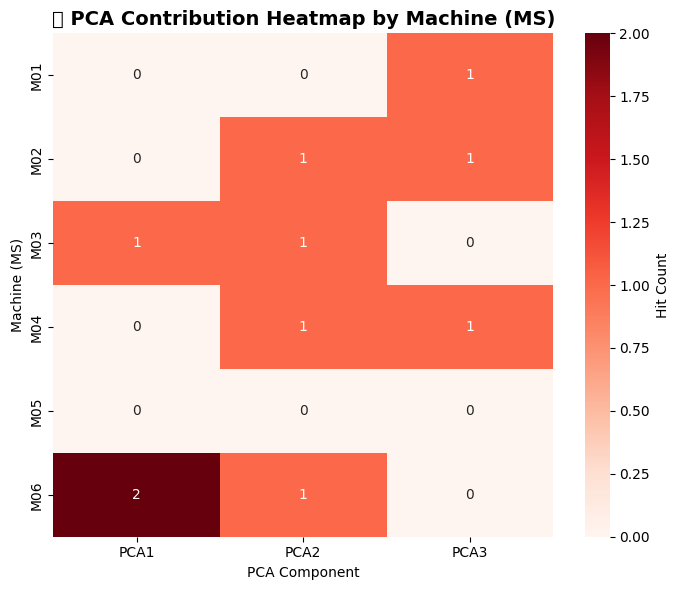

📊 MS 機台 PCA 命中統計（依總命中次數排序）

     PCA1  PCA2  PCA3  Total_Hits  Num_PCAs
M06     2     1     0           3         3
M02     0     1     1           2         3
M04     0     1     1           2         3
M03     1     1     0           2         3
M01     0     0     1           1         2
M05     0     0     0           0         0

🔎 熱點觀察：
✅ 機台 M06 是目前最高命中的機台（共 3 次）
✅ 機台 ['M06', 'M02', 'M04', 'M03', 'M01'] 涉及多個 PCA 主軸，可能為跨維度瓶頸

📘 分類建議：
👉 M06: 熱點分佈廣，應優先檢查資源與排程負載
👉 M02: 熱點分佈廣，應優先檢查資源與排程負載
👉 M04: 熱點分佈廣，應優先檢查資源與排程負載
👉 M03: 熱點分佈廣，應優先檢查資源與排程負載
👉 M01: 熱點分佈廣，應優先檢查資源與排程負載


In [ ]:
def summarize_pca_machine_hits(df):
    """
    根據 PCA 熱點圖 DataFrame，統計並解釋機台命中分布情況。
    """
    summary = df.copy()
    summary["Total_Hits"] = summary.sum(axis=1)
    summary["Num_PCAs"] = (summary > 0).sum(axis=1)

    # 排序後印出總覽
    sorted_df = summary.sort_values(by="Total_Hits", ascending=False)
    print("📊 MS 機台 PCA 命中統計（依總命中次數排序）\n")
    print(sorted_df)

    # 找出最高熱區
    top_machine = sorted_df.index[0]
    max_hits = sorted_df.iloc[0]["Total_Hits"]
    multi_pca = sorted_df[sorted_df["Num_PCAs"] >= 2]

    print(f"\n🔎 熱點觀察：")
    print(f"✅ 機台 {top_machine} 是目前最高命中的機台（共 {int(max_hits)} 次）")
    print(f"✅ 機台 {list(multi_pca.index)} 涉及多個 PCA 主軸，可能為跨維度瓶頸")

    # 分類建議
    print("\n📘 分類建議：")
    for idx, row in sorted_df.iterrows():
        total = int(row["Total_Hits"])
        pcas = int(row["Num_PCAs"])
        if total == 0:
            continue
        if pcas >= 2:
            print(f"👉 {idx}: 熱點分佈廣，應優先檢查資源與排程負載")
        elif pcas == 1 and total >= 2:
            print(f"👉 {idx}: 單一主軸重複命中，可能是特定變異來源集中機台")

    return sorted_df

df_heatmap = analyze_ms_pca_heatmap(J, mean_trajectory[-1], pca_highlight_dict, machine_num)
summary = summarize_pca_machine_hits(df_heatmap)